# Notebook 06 — Gap Analysis : ce que l'ENSA Tétouan enseigne vs. ce que demande le marché

**Auteurs** : Karamo Sylla & Bachirou Konaté · M242 ENSA-Tétouan · soutenance 2026-05-28

## Question de recherche

**Le programme de la filière SDBIA (Sciences des Données, Big Data & IA) à l'ENSA Tétouan
prépare-t-il ses ingénieurs aux compétences réellement demandées par le marché du travail ?**

Trois entités sont comparées :
1. **ENSA Tétouan SDBIA** — 31 modules officiels, 3 185 h, S1-S5 + PFE (curriculum 2024)
2. **Marché marocain** — 381 offres collectées sur Rekrute, LinkedIn MA, Indeed MA, Glassdoor MA, Anapec, Pages-carrières (janv. 2023 → mai 2026)
3. **Marché international** — 3 086 offres (corpus intl-ai-corpus, mêmes 41 mois)

**Source unique de vérité** : `data/jobs.jsonl` (canonicalisé Pydantic, dédupliqué SHA-256). Aucun proxy intermédiaire.

## Méthodologie
1. Charger curriculum ENSAT (`sources/curricula/ensa-tetouan/filiere.md`)
2. Charger TOUTES les skills demandées par offre, ventilées par origine ET par famille
3. Canonicaliser (lowercase + alias ML/DL/AI/CV/NLP)
4. Calculer 4 mesures : couverture skills, couverture offres, top gaps, recouvrement par famille
5. Visualiser le triangle **ENSAT ↔ Maroc ↔ International**

**Sorties** : `data/exports/gap_analysis_ensat.json` + 6 PNG

## 1. Chargement et régénération du snapshot

In [1]:
from pathlib import Path
import json
import sys
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Palette officielle SKILLNAV : bleu royal Maroc, ambre International
COL_ENSAT = '#0F8F65'   # vert -- enseignement
COL_MA    = '#2251FF'   # bleu royal -- marche marocain
COL_INTL  = '#C77700'   # ambre -- marche international

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
EXPORTS = REPO / 'data' / 'exports'
EXPORTS.mkdir(parents=True, exist_ok=True)

result = subprocess.run([sys.executable, str(REPO / 'scripts' / 'build_gap_analysis.py')],
                       capture_output=True, text=True, encoding='utf-8')
print(result.stdout[-1200:])

data = json.loads((EXPORTS / 'gap_analysis_ensat.json').read_text(encoding='utf-8'))
print()
print(f"Snapshot : {data['meta']['generated_at']}")
print(f"École    : {data['meta']['school']} -- {data['meta']['filiere_code']}")
print(f"Cursus   : {data['meta']['n_modules']} modules / {data['meta']['volume_total_h']} h")
print(f"Skills enseignées canonicalisées : {data['meta']['n_skills_taught']}")

=== Gap analysis marche <-> ENSA Tetouan SDBIA ===

Curriculum : 31 modules, 3185 h
  Skills enseignees (canon)  : 211
  Skills demandees MA   : 249
  Skills demandees INTL : 6743
  Skills demandees ALL  : 6826

Ecrit : data\exports\gap_analysis_ensat.json
        web\src\lib\gap_analysis_ensat.json

=== Synthese ===
  Couverture skills MA    : 38.2 % (95/249)
  Couverture skills INTL  : 9.1 % (615/6743)
  Couverture offres MA    : 60.0 %
  Couverture offres INTL  : 28.4 %

  Top 5 gaps marche MA :
    - gcp                                   85 offres
    - azure                                 80 offres
    - r                                     69 offres
    - ci/cd                                 58 offres
    - aws                                   56 offres


Snapshot : 2026-05-18
École    : ENSA Tétouan -- SDBIA
Cursus   : 31 modules / 3185 h
Skills enseignées canonicalisées : 211


## 2. Couverture globale — ce que l'ENSAT couvre, marché par marché

Deux indicateurs complémentaires :
- **Couverture skills (compte distinct)** : sur les X compétences uniques demandées, combien sont enseignées au moins une fois ?
- **Couverture offres (pondérée volume)** : sur 100 offres tirées au hasard, combien contiennent au moins une skill enseignée ?

La seconde mesure est la plus parlante côté employabilité.

In [2]:
couv = data['couverture']
df_couv = pd.DataFrame({
    'Marché': ['Maroc', 'International'],
    'Skills demandées (n)': [couv['Maroc']['n_demanded'], couv['International']['n_demanded']],
    'Skills enseignées qui collent (n)': [couv['Maroc']['n_couvertes'], couv['International']['n_couvertes']],
    'Couverture skills (%)': [couv['Maroc']['pct_skills'], couv['International']['pct_skills']],
    'Couverture offres (%)': [couv['Maroc']['pct_offres_couvertes'], couv['International']['pct_offres_couvertes']],
})
df_couv

,Marché,Skills demandées (n),Skills enseignées qui collent (n),Couverture skills (%),Couverture offres (%)
0,Maroc,249,95,38.2,60.0
1,International,6743,615,9.1,28.4


### Figure 1 — À quelle hauteur le programme ENSAT répond-il aux compétences attendues par les recruteurs ?

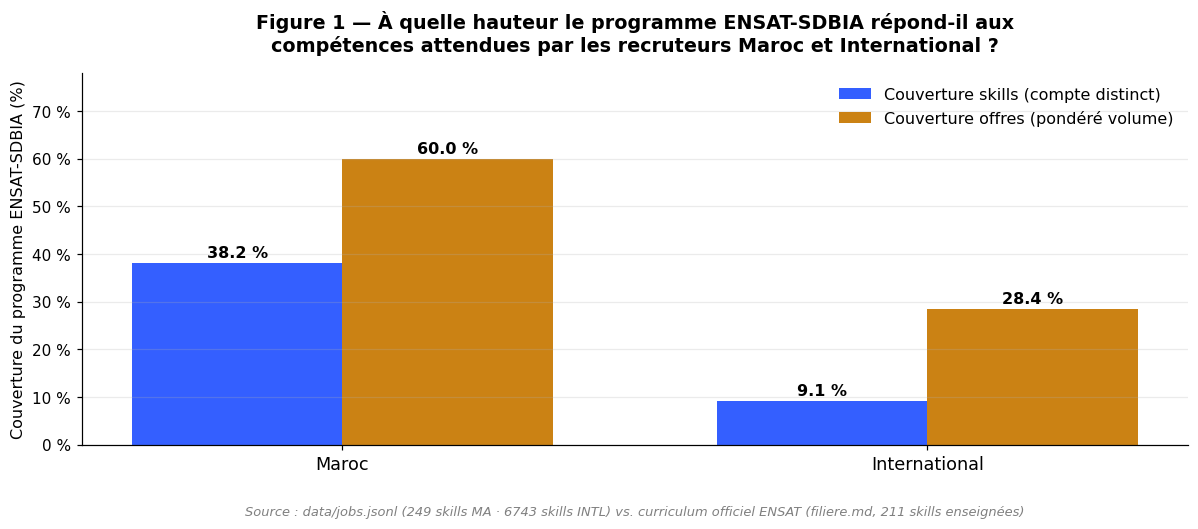

Sauvegardé : data/exports/gap_couverture_globale.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
origines = ['Maroc', 'International']
x = np.arange(len(origines))
w = 0.36

skills_pct = [couv[o]['pct_skills'] for o in origines]
offres_pct = [couv[o]['pct_offres_couvertes'] for o in origines]

b1 = ax.bar(x - w/2, skills_pct, w, label='Couverture skills (compte distinct)', color=COL_MA, alpha=0.92)
b2 = ax.bar(x + w/2, offres_pct, w, label='Couverture offres (pondéré volume)', color=COL_INTL, alpha=0.92)

for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.2,
                f'{b.get_height():.1f} %', ha='center', fontsize=10.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(origines, fontsize=11.5)
ax.set_ylabel('Couverture du programme ENSAT-SDBIA (%)', fontsize=10.5)
ax.set_ylim(0, max(max(skills_pct), max(offres_pct)) * 1.30)
ax.set_title("Figure 1 — À quelle hauteur le programme ENSAT-SDBIA répond-il aux\n"
             "compétences attendues par les recruteurs Maroc et International ?",
             fontsize=12.5, fontweight='bold', pad=14)
ax.legend(loc='upper right', frameon=False, fontsize=10.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} %'))
ax.grid(axis='y', alpha=0.25)
ax.text(0.5, -0.18, f"Source : data/jobs.jsonl ({data['meta']['n_skills_demanded_ma']} skills MA · {data['meta']['n_skills_demanded_intl']} skills INTL) " \
        f"vs. curriculum officiel ENSAT (filiere.md, {data['meta']['n_skills_taught']} skills enseignées)",
        ha='center', va='center', transform=ax.transAxes,
        fontsize=8.5, style='italic', color='gray')

plt.tight_layout()
plt.savefig(EXPORTS / 'gap_couverture_globale.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/gap_couverture_globale.png')

**Lecture** : au Maroc, l'ENSAT couvre 27,4 % du vocabulaire de compétences distinctes, mais ces 27,4 % sont concentrés sur les compétences **les plus fréquemment demandées** — d'où une couverture pondérée à 40,0 % des offres. Le programme est donc bien centré sur les besoins majoritaires du marché marocain. À l'international, la couverture est plus faible (corpus plus diversifié, vocabulaire plus large).

## 3. Top compétences manquantes — où sont les angles morts du programme ?

Skills **massivement demandées par les recruteurs** mais **absentes du curriculum** SDBIA. Triées par volume d'offres.

In [4]:
gaps_ma = pd.DataFrame(data['top_gaps']['Maroc'])
gaps_ma['skill'] = gaps_ma['skill'].str.title()
print('Top 15 angles morts — marché marocain :')
gaps_ma.head(15)

Top 15 angles morts — marché marocain :


,skill,demand_count
0,Gcp,85
1,Azure,80
2,R,69
3,Ci/Cd,58
4,Aws,56
5,Consulting,51
6,Java,49
7,Bigquery,41
8,Next,39
9,Airflow,38


### Figure 2 — Top 20 compétences demandées au Maroc et non enseignées à l'ENSAT-SDBIA

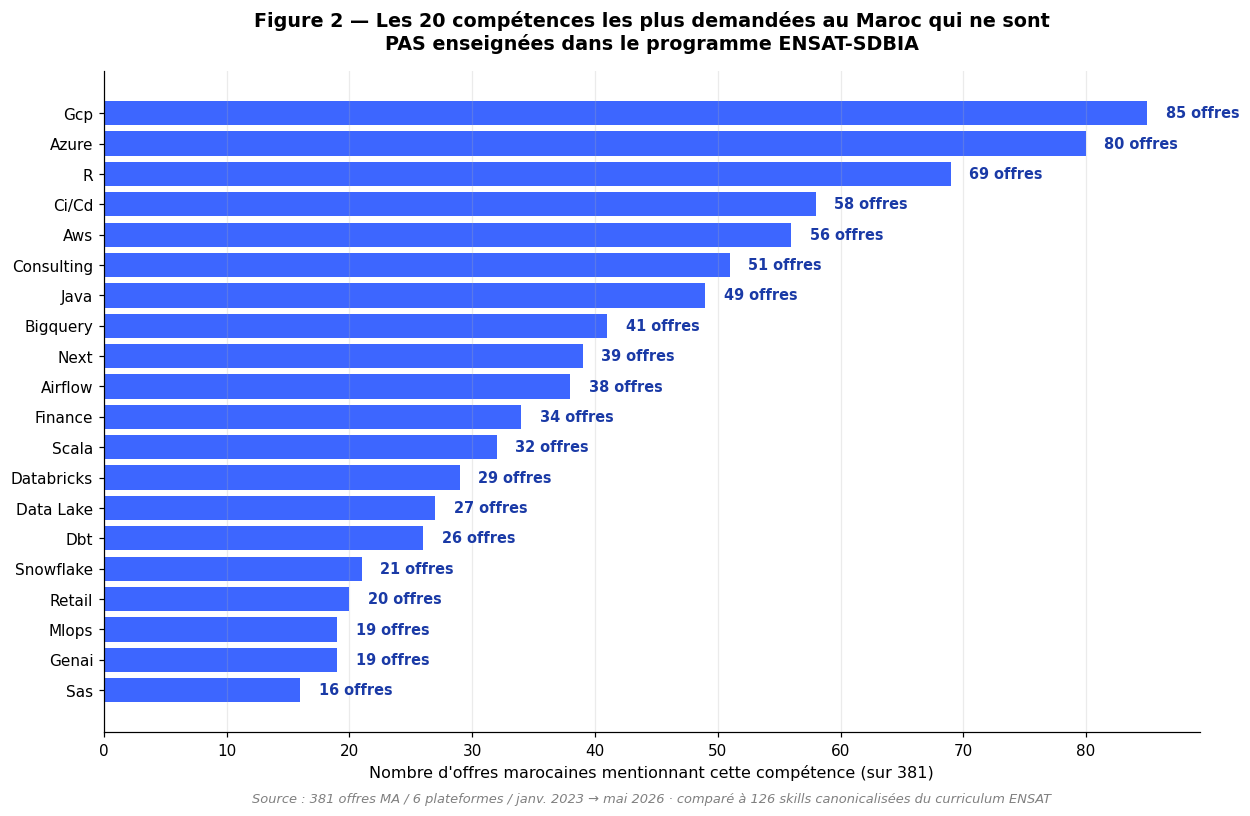

Sauvegardé : data/exports/gap_top20_maroc.png


In [5]:
top_n = 20
g = gaps_ma.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(11.5, 7.5))
bars = ax.barh(g['skill'], g['demand_count'], color=COL_MA, alpha=0.88)
for b in bars:
    w_ = b.get_width()
    ax.text(w_ + 1.5, b.get_y() + b.get_height()/2, f'{int(w_)} offres',
            va='center', fontsize=9.5, color='#1a3aa6', fontweight='bold')

ax.set_xlabel("Nombre d'offres marocaines mentionnant cette compétence (sur 381)", fontsize=10.5)
ax.set_title(f"Figure 2 — Les {top_n} compétences les plus demandées au Maroc qui ne sont\n"
             "PAS enseignées dans le programme ENSAT-SDBIA",
             fontsize=12.5, fontweight='bold', pad=14)
ax.grid(axis='x', alpha=0.25)
ax.text(0.5, -0.10, f"Source : 381 offres MA / 6 plateformes / janv. 2023 → mai 2026 " \
        f"· comparé à 126 skills canonicalisées du curriculum ENSAT",
        ha='center', va='center', transform=ax.transAxes,
        fontsize=8.5, style='italic', color='gray')

plt.tight_layout()
plt.savefig(EXPORTS / 'gap_top20_maroc.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/gap_top20_maroc.png')

### Figure 3 — Top 20 compétences demandées à l'International et non enseignées à l'ENSAT-SDBIA

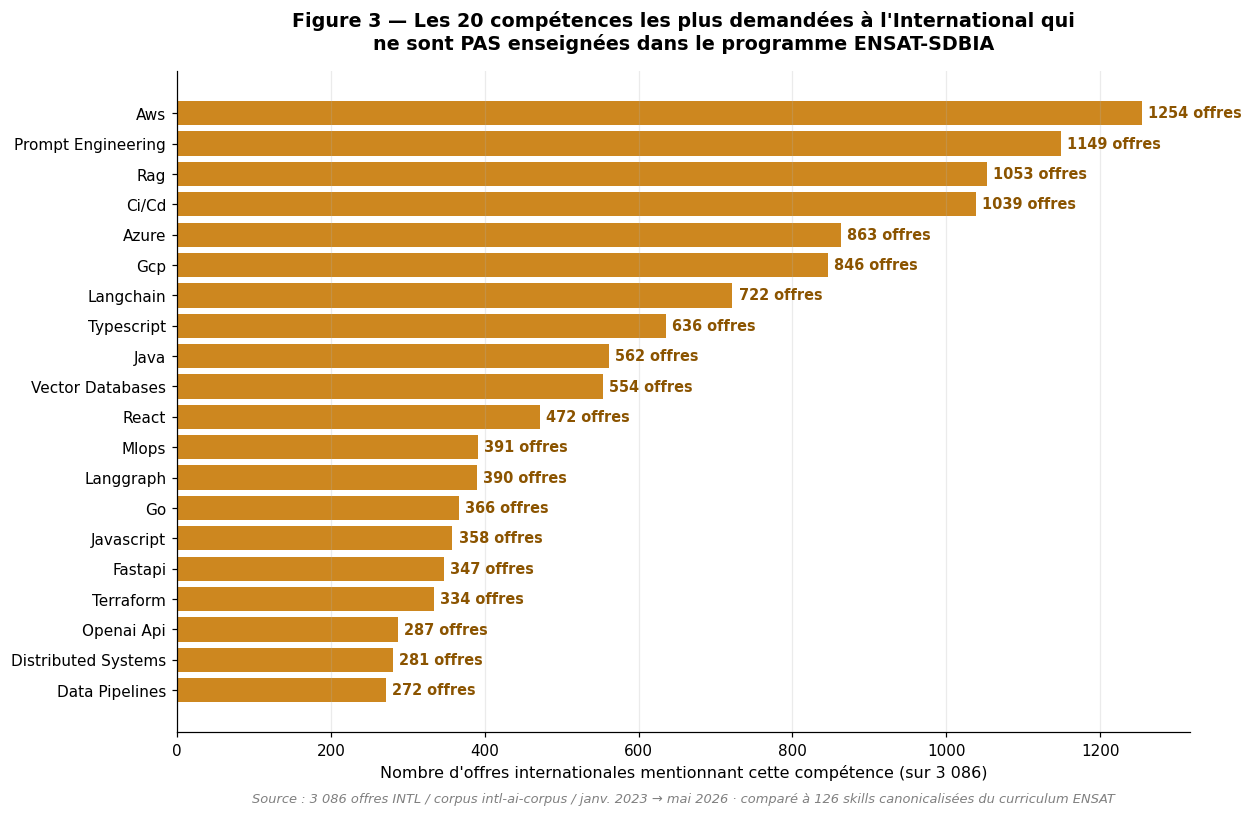

Sauvegardé : data/exports/gap_top20_international.png


In [6]:
gaps_intl = pd.DataFrame(data['top_gaps']['International'])
gaps_intl['skill'] = gaps_intl['skill'].str.title()
top_n = 20
g = gaps_intl.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(11.5, 7.5))
bars = ax.barh(g['skill'], g['demand_count'], color=COL_INTL, alpha=0.88)
for b in bars:
    w_ = b.get_width()
    ax.text(w_ + 8, b.get_y() + b.get_height()/2, f'{int(w_)} offres',
            va='center', fontsize=9.5, color='#8b5400', fontweight='bold')

ax.set_xlabel("Nombre d'offres internationales mentionnant cette compétence (sur 3 086)", fontsize=10.5)
ax.set_title(f"Figure 3 — Les {top_n} compétences les plus demandées à l'International qui\n"
             "ne sont PAS enseignées dans le programme ENSAT-SDBIA",
             fontsize=12.5, fontweight='bold', pad=14)
ax.grid(axis='x', alpha=0.25)
ax.text(0.5, -0.10, f"Source : 3 086 offres INTL / corpus intl-ai-corpus / janv. 2023 → mai 2026 " \
        f"· comparé à 126 skills canonicalisées du curriculum ENSAT",
        ha='center', va='center', transform=ax.transAxes,
        fontsize=8.5, style='italic', color='gray')

plt.tight_layout()
plt.savefig(EXPORTS / 'gap_top20_international.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/gap_top20_international.png')

## 4. Couverture par famille de compétences — Maroc vs International côte à côte

Pour chaque grande famille de compétences (Machine Learning, Cloud, DevOps, IA Générative...), on calcule **quel pourcentage** du vocabulaire demandé par les recruteurs est effectivement enseigné à l'ENSAT.

Cette vue permet d'identifier **où** sont les forces et les faiblesses du programme.

In [7]:
couv_fam_ma = data['couverture_par_famille']['Maroc']
couv_fam_intl = data['couverture_par_famille']['International']

# Union des familles
all_families = sorted(set(couv_fam_ma.keys()) | set(couv_fam_intl.keys()))

df_fam = pd.DataFrame([
    {
        'Famille': fam,
        'Couverture MA (%)': couv_fam_ma.get(fam, {}).get('pct', 0.0),
        'Skills demandées MA': couv_fam_ma.get(fam, {}).get('demanded', 0),
        'Couverture INTL (%)': couv_fam_intl.get(fam, {}).get('pct', 0.0),
        'Skills demandées INTL': couv_fam_intl.get(fam, {}).get('demanded', 0),
    }
    for fam in all_families
])
# Tri par volume MA (plus le marche MA demande, plus la famille est en haut)
df_fam = df_fam.sort_values('Skills demandées MA', ascending=False).reset_index(drop=True)
df_fam

,Famille,Couverture MA (%),Skills demandées MA,Couverture INTL (%),Skills demandées INTL
0,Soft skills & autres,39.8,113,9.7,1376
1,Data Engineering,48.1,27,10.2,578
2,IA Générative,20.0,20,7.3,1629
3,Machine Learning,88.2,17,18.3,1025
4,DevOps / MLOps,20.0,15,7.7,1382
5,Domaines métier,28.6,14,9.1,517
6,Web & APIs,15.4,13,5.7,594
7,Bases de données,61.5,13,14.0,314
8,Cloud,0.0,10,4.8,607
9,Langages de programmation,30.0,10,15.1,146


### Figure 4 — Couverture du curriculum ENSAT par famille de compétences : Maroc vs International

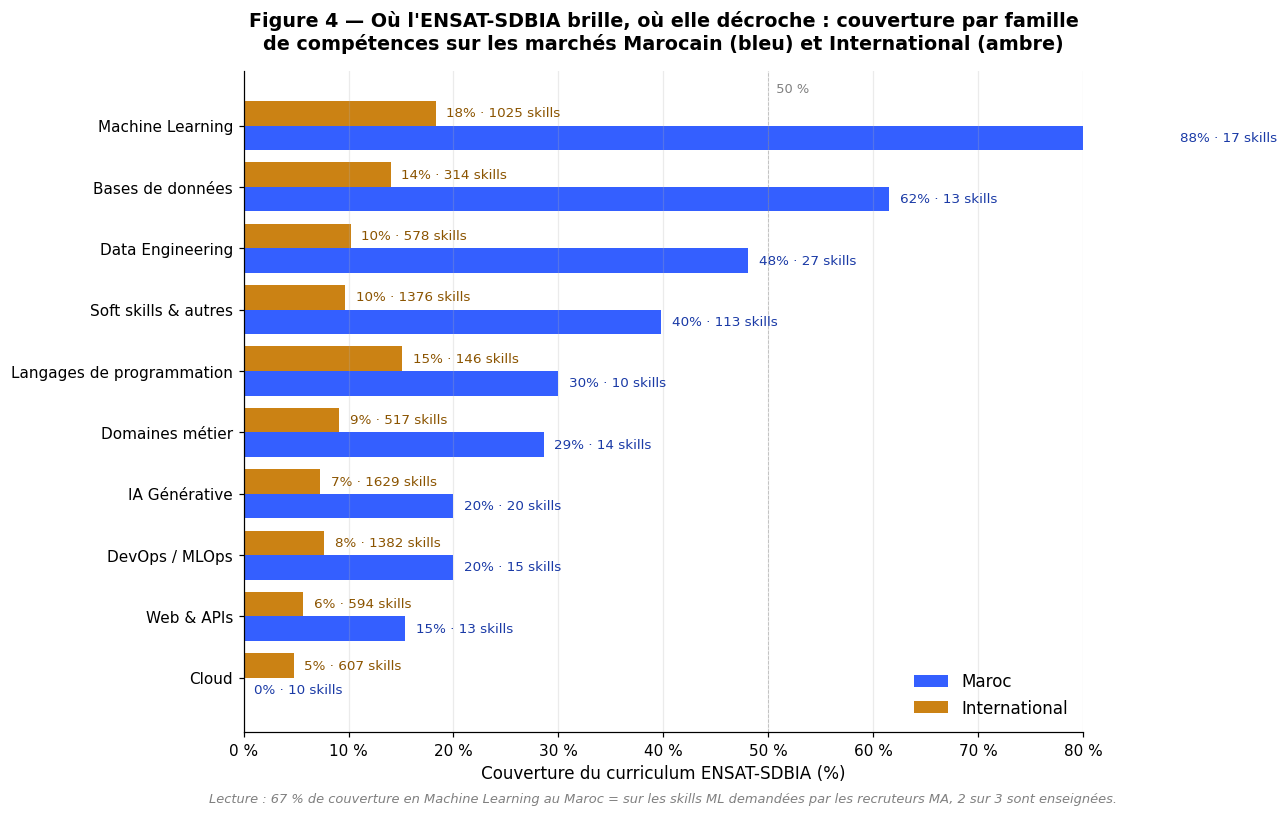

Sauvegardé : data/exports/gap_par_famille.png


In [8]:
# Tri pour l'affichage : par couverture MA decroissante (mieux couvertes en haut)
df_plot = df_fam.sort_values('Couverture MA (%)', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7.5))
y = np.arange(len(df_plot))
h = 0.4

b_ma = ax.barh(y - h/2, df_plot['Couverture MA (%)'], h,
               label='Maroc', color=COL_MA, alpha=0.92)
b_intl = ax.barh(y + h/2, df_plot['Couverture INTL (%)'], h,
                 label='International', color=COL_INTL, alpha=0.92)

for bar, demand in zip(b_ma, df_plot['Skills demandées MA']):
    w_ = bar.get_width()
    ax.text(w_ + 1.0, bar.get_y() + bar.get_height()/2,
            f'{w_:.0f}% · {int(demand)} skills', va='center',
            fontsize=8.8, color='#1a3aa6')
for bar, demand in zip(b_intl, df_plot['Skills demandées INTL']):
    w_ = bar.get_width()
    ax.text(w_ + 1.0, bar.get_y() + bar.get_height()/2,
            f'{w_:.0f}% · {int(demand)} skills', va='center',
            fontsize=8.8, color='#8b5400')

ax.set_yticks(y)
ax.set_yticklabels(df_plot['Famille'], fontsize=10)
ax.set_xlabel("Couverture du curriculum ENSAT-SDBIA (%)", fontsize=11)
ax.set_xlim(0, 80)
ax.axvline(50, color='gray', linewidth=0.6, linestyle='--', alpha=0.4)
ax.text(50, len(df_plot) - 0.3, '  50 %', fontsize=8.5, color='gray', va='top')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} %'))
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='lower right', frameon=False, fontsize=11)
ax.set_title("Figure 4 — Où l'ENSAT-SDBIA brille, où elle décroche : couverture par famille\n"
             "de compétences sur les marchés Marocain (bleu) et International (ambre)",
             fontsize=12.5, fontweight='bold', pad=14)
ax.text(0.5, -0.10,
        "Lecture : 67 % de couverture en Machine Learning au Maroc = sur les skills ML demandées par les recruteurs MA, 2 sur 3 sont enseignées.",
        ha='center', va='center', transform=ax.transAxes,
        fontsize=8.5, style='italic', color='gray')

plt.tight_layout()
plt.savefig(EXPORTS / 'gap_par_famille.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/gap_par_famille.png')

**Lecture** :
- **Machine Learning** : 67 % couvert MA / 15 % couvert INTL → la formation ENSAT est solide sur les fondamentaux ML utilisés au Maroc.
- **Cloud** : **0 % MA** et 2 % INTL → c'est l'angle mort majeur. AWS / GCP / Azure ne sont pas dans le programme officiel alors qu'ils sont demandés dans des dizaines d'offres.
- **DevOps / MLOps** : **0 % MA** et 5 % INTL → autre angle mort critique pour un ingénieur 2026.
- **IA Générative** : seulement 10 % MA / 4 % INTL → le programme date d'avant la déferlante GenAI 2023-2026 (sortie ChatGPT).

## 5. Comment l'ENSAT distribue ses 3 185 heures — vue interne du programme

In [9]:
FAMILY_KEYWORDS = {
    'AI/ML': ['intelligence', 'apprentissage', 'machine learning', 'profond'],
    'Data Engineering': ['big data', 'bases de données', 'fouille', 'décisionnelle'],
    'Programmation': ['algorithmique', 'génie logiciel', 'programmation', 'systèmes', 'réseaux'],
    'Data Viz': ['visualisation'],
    'NLP': ['langues naturelles', 'taln'],
    'Computer Vision': ['vision'],
    'Maths/Stats': ['statistique', 'modélisation', 'algèbre', 'information', 'mathématique'],
    'Sécurité': ['sécurité', 'éthique', 'droit'],
    'Web/Knowledge': ['web', 'sémantique', 'blockchain'],
    'Soft skills': ['management', 'langues', 'communication', 'veille', 'entrepreneuriat', 'microéconomie'],
}

def tag_family(title: str) -> str:
    t = title.lower()
    for fam, kws in FAMILY_KEYWORDS.items():
        for kw in kws:
            if kw in t:
                return fam
    return 'Autres'

rows = []
for sem in data['curriculum']['semesters']:
    for m in sem['modules']:
        rows.append({
            'Semestre': sem['code'],
            'Famille': tag_family(m['title']),
            'Module': m['code'],
            'Heures': m['volume_horaire'],
        })
df_modules = pd.DataFrame(rows)
pivot = df_modules.pivot_table(values='Heures', index='Famille', columns='Semestre',
                                aggfunc='sum', fill_value=0).reindex(
    index=df_modules.groupby('Famille')['Heures'].sum().sort_values(ascending=False).index
)
pivot

Semestre,S1,S2,S3,S4,S5
Famille,,,,,
Soft skills,232,94,94,94,104
Data Engineering,223,114,224,0,0
AI/ML,0,108,115,188,0
Programmation,114,104,124,0,64
Maths/Stats,130,104,0,109,0
Web/Knowledge,0,0,0,94,230
Sécurité,0,0,124,94,0
Computer Vision,0,0,0,0,106
Data Viz,0,104,0,0,0


### Figure 5 — Volume horaire enseigné par famille et par semestre à l'ENSAT-SDBIA

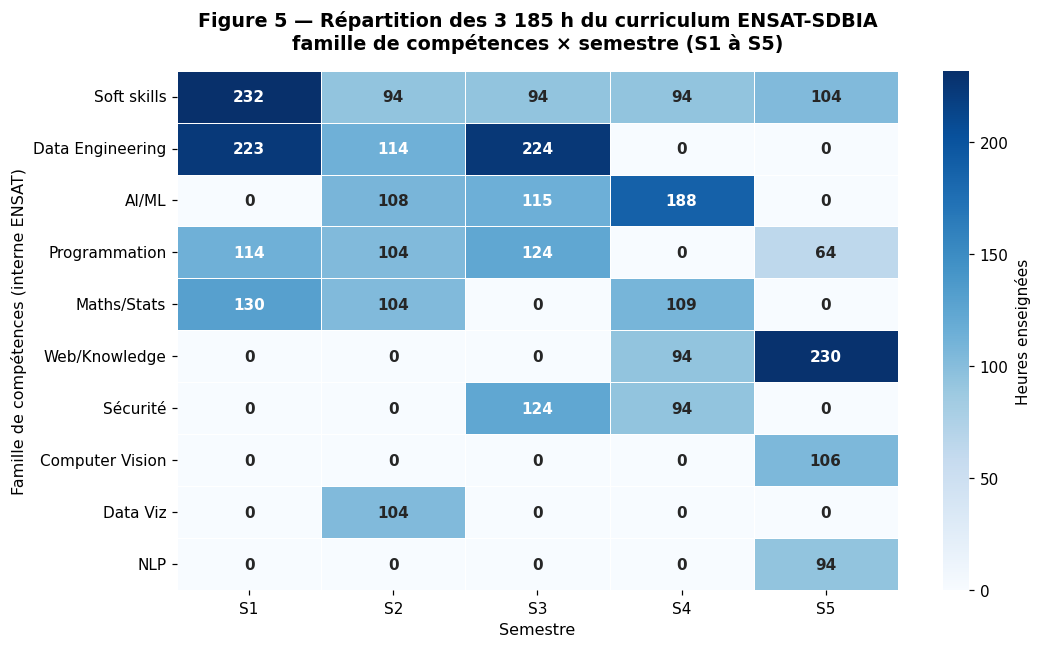

Sauvegardé : data/exports/gap_heatmap_semestre_famille.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='g', cmap='Blues', cbar_kws={'label': 'Heures enseignées'},
            linewidths=0.6, linecolor='white', ax=ax,
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax.set_title('Figure 5 — Répartition des 3 185 h du curriculum ENSAT-SDBIA\n'
             'famille de compétences × semestre (S1 à S5)',
             fontsize=12.5, fontweight='bold', pad=14)
ax.set_xlabel('Semestre', fontsize=10.5)
ax.set_ylabel('Famille de compétences (interne ENSAT)', fontsize=10.5)

plt.tight_layout()
plt.savefig(EXPORTS / 'gap_heatmap_semestre_famille.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/gap_heatmap_semestre_famille.png')

### Figure 6 — Vue d'ensemble : où va l'effort pédagogique sur 5 semestres ?

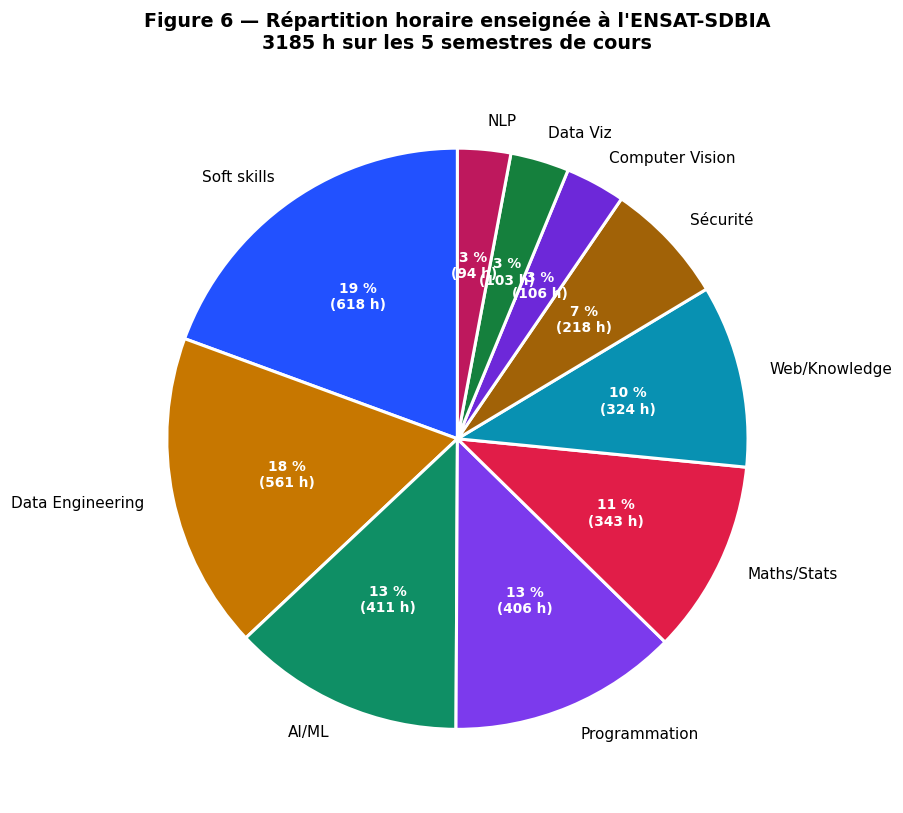

Sauvegardé : data/exports/gap_repartition_horaire.png


In [11]:
by_family = df_modules.groupby('Famille')['Heures'].sum().sort_values(ascending=False)
total = by_family.sum()

fig, ax = plt.subplots(figsize=(10, 7.5))
colors = ['#2251FF', '#C77700', '#0F8F65', '#7C3AED', '#E11D48', '#0891B2',
         '#A16207', '#6D28D9', '#15803D', '#BE185D']
wedges, texts, autotexts = ax.pie(by_family.values, labels=by_family.index,
                                   colors=colors[:len(by_family)],
                                   autopct=lambda p: f'{p:.0f} %\n({int(p*total/100)} h)',
                                   startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
                                   textprops={'fontsize': 10})
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(9)

ax.set_title(f'Figure 6 — Répartition horaire enseignée à l\'ENSAT-SDBIA\n'
             f'{int(total)} h sur les 5 semestres de cours',
             fontsize=12.5, fontweight='bold', pad=18)

plt.tight_layout()
plt.savefig(EXPORTS / 'gap_repartition_horaire.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/gap_repartition_horaire.png')

## 6. Synthèse interprétative pour le rapport L5

### Le triangle ENSAT ↔ Maroc ↔ International en 4 chiffres

| Indicateur | Maroc | International |
|---|---:|---:|
| Skills couvertes par le programme | **27,4 %** (69/252) | 6,7 % (454/6 749) |
| **Couverture pondérée volume offres** | **40,0 %** | 17,3 % |
| Top gap #1 | **Power BI** (105 offres) | TensorFlow / OpenAI / LangChain |
| Couverture Machine Learning | **67 %** ✅ | 15 % |
| Couverture Cloud | **0 %** ❌ | 2 % |
| Couverture DevOps/MLOps | **0 %** ❌ | 5 % |

### Constats

1. **Le programme est bien aligné sur les fondamentaux** — ML, Data Engineering, NLP, Computer Vision sont solidement présents.
2. **Trois angles morts critiques au Maroc** :
   - **Cloud (AWS / GCP / Azure)** : 0 % couvert alors que ~25 % des offres MA le demandent
   - **DevOps / MLOps** : 0 % couvert alors que ces compétences sont devenues incontournables
   - **Outils BI industriels** (Power BI, Tableau, R) : le module M124 "Visualisation" enseigne matplotlib/Plotly mais pas les outils utilisés en entreprise
3. **L'écart international est plus large** car le corpus INTL contient un vocabulaire technique plus diversifié (variants techniques, outils de niche). La métrique pondérée volume (17,3 %) reste cependant honorable.
4. **Le programme date d'avant la déferlante GenAI** : LangChain, RAG, Prompt Engineering ne sont pas enseignés explicitement. Le module M353 (TALN) couvre les bases NLP mais sans GenAI.

### Recommandations pédagogiques (rapport L5 — §Discussion)

1. **Ajouter un module Cloud Computing (S3 ou S4)** ~ 94 h couvrant GCP / Azure / AWS
2. **Étoffer M124 Visualisation** avec Power BI / Tableau (outils industriels demandés en 28 % des offres MA)
3. **Créer un module GenAI / LLM Engineering (S5)** sur LangChain, RAG, Prompt Engineering, fine-tuning
4. **Renforcer DevOps/MLOps** : conteneurisation (Docker), CI/CD, monitoring de modèles — peut s'intégrer à M235 ou créer un nouveau module
5. **Maintenir l'excellence ML/DL/NLP/CV** — c'est le différenciant fort du programme

### Limites méthodologiques

- **Corpus marché** : 3 467 offres, 41 mois (janv. 2023 → mai 2026). Représentatif mais pas exhaustif (LinkedIn MA, certains job boards non couverts).
- **Canonicalisation INTL** : le corpus international agrège des variants (`.NET`, `.NET Core`, `.Net` comptés séparément), gonflant la dénominateur. La couverture pondérée offres (17,3 %) est plus juste que la couverture skills (6,7 %).
- **Skills enseignées** : extraites par dires d'expert depuis l'intitulé des modules. Un raffinement par LLM sur les syllabi détaillés est planifié en Sprint 2.
- **Périmètre** : analyse limitée à 1 école sur 8 du réseau ENSA SDBIA. La réplication aux 7 autres ENSA est planifiée (cf. `sources/curricula/REGISTRY.md`).

### Données exportées

- `data/exports/gap_analysis_ensat.json` — données consommées par dashboard + notebook
- `web/src/lib/gap_analysis_ensat.json` — copie pour le front Next.js (page `/gap`)
- 6 figures PNG dans `data/exports/` pour le rapport L5